# Safe Model Rollout: Rejecting an Unqualified Challenger

**Chapter 26: MLOps and Governance**
**Execution environment**: local `uv`, CPU-only
**Book Reference**: Chapter 26, Section 26.4
**Prerequisites**: Chapter 25 deployment verification and the monitoring workflow from
Sections 26.2-26.3.

**Learning Objectives**:
- Bind author-chosen incumbent and challenger roles to fixed stored prediction artifacts.
- Interpret pre-rollout Spearman IC as descriptive context rather than a selection rule.
- Evaluate a challenger during a fixed 63-session shadow window.
- Reject a challenger that misses a fixed promotion hurdle without exposing capital.

The case study supplies real `fwd_ret_1d` prediction histories for OLS and Ridge models. This
author-chosen illustrative scenario fixes OLS as the incumbent and Ridge as the challenger before
examining performance. The 2010-2014 interval supplies descriptive historical context, shadow
evaluation uses the first 63 trading sessions of 2015, and the 2016-2018 holdout remains sealed.

This example deliberately ends at rejection. A safe rollout does not owe every challenger an A/B
test or staged capital. Those steps become eligible only after every shadow criterion passes.

In [1]:
"""Reject an unqualified model challenger after a fixed shadow evaluation."""

'Reject an unqualified model challenger after a fixed shadow evaluation.'

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
HISTORICAL_START = "2010-01-01"
HISTORICAL_END = "2014-12-31"
ROLLOUT_START = "2015-01-01"
ROLLOUT_END = "2015-12-31"
SHADOW_SESSIONS = 63
TOP_K = 100
SEED = 42

In [3]:
import os
import sqlite3
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display

from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis

set_global_seeds(SEED)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"
REGISTRY_DB = Path(os.environ.get("ML4T_REGISTRY_SNAPSHOT", CASE_DIR / "run_log" / "registry.db"))
FIXED_OLS_PREDICTION_HASH = "f9e84a32a9f0"
FIXED_RIDGE_PREDICTION_HASH = "b381d21ffa4a"

## 1. Bind the illustrative model identities

The teaching scenario fixes OLS as incumbent and Ridge as challenger. These roles are an author
choice, not the result of a point-in-time model-selection exercise. Exact prediction hashes make
the illustrative comparison reproducible and make any later artifact mismatch fail closed.

In [4]:
@dataclass(frozen=True)
class PredictionIdentity:
    """A materialized validation prediction artifact."""

    config_name: str
    training_hash: str
    prediction_hash: str

The registry connection is read-only and immutable because candidate review must not mutate the
case-study result record.

In [5]:
def open_registry_readonly(path: Path) -> sqlite3.Connection:
    """Open an immutable, query-only SQLite connection."""
    uri = f"file:{path.resolve()}?mode=ro&immutable=1"
    connection = sqlite3.connect(uri, uri=True)
    connection.execute("PRAGMA query_only=ON")
    return connection

Each fixed role requires its exact materialized validation prediction set. Registry rows without
the expected content-addressed Parquet artifact cannot satisfy the scenario contract.

In [6]:
def load_fixed_prediction_identity(model: str) -> PredictionIdentity:
    """Load the exact prediction artifact assigned to one illustrative role."""
    if model == "linear_ols":
        config_filter = "tr.config_name = 'ols'"
        expected_hash = FIXED_OLS_PREDICTION_HASH
    elif model == "linear_ridge":
        config_filter = "tr.config_name LIKE 'ridge%'"
        expected_hash = FIXED_RIDGE_PREDICTION_HASH
    else:
        raise ValueError(f"Unsupported model identity: {model}")

    query = f"""
        SELECT tr.config_name, tr.training_hash, ps.prediction_hash
        FROM training_runs tr
        JOIN prediction_sets ps ON tr.training_hash = ps.training_hash
        WHERE tr.family = 'linear'
          AND tr.label = ?
          AND ps.split = 'validation'
          AND ps.prediction_hash = ?
          AND {config_filter}
        ORDER BY tr.config_name, tr.training_hash
    """
    predictions_dir = CASE_DIR / "run_log" / "predictions"
    with open_registry_readonly(REGISTRY_DB) as connection:
        rows = connection.execute(query, (PRIMARY_LABEL, expected_hash)).fetchall()
    materialized = [
        row for row in rows if (predictions_dir / row[2] / "predictions.parquet").is_file()
    ]
    identities = {PredictionIdentity(*row) for row in materialized}
    if len(identities) != 1:
        raise RuntimeError(
            f"Fixed illustrative artifact {expected_hash} for {model} is missing or ambiguous"
        )
    return identities.pop()

Roles are assigned directly before any performance statistic is calculated. Historical IC below
describes these fixed artifacts; it does not select or validate the Ridge challenger.

In [7]:
incumbent = "linear_ols"
candidate = "linear_ridge"
OLS_IDENTITY = load_fixed_prediction_identity(incumbent)
RIDGE_IDENTITY = load_fixed_prediction_identity(candidate)

identity_summary = pd.DataFrame(
    [
        {
            "role": "incumbent",
            "model": incumbent,
            "configuration": OLS_IDENTITY.config_name,
            "prediction_hash": OLS_IDENTITY.prediction_hash,
        },
        {
            "role": "challenger",
            "model": candidate,
            "configuration": RIDGE_IDENTITY.config_name,
            "prediction_hash": RIDGE_IDENTITY.prediction_hash,
        },
    ]
)
identity_summary

,role,model,configuration,prediction_hash
0,incumbent,linear_ols,ols,f9e84a32a9f0
1,challenger,linear_ridge,ridge_a100000.0,b381d21ffa4a


## 2. Reconstruct historical context and shadow streams

Transaction cost uses the midpoint of the configured per-leg range. The same cost rule applies to
both models.

In [8]:
def load_cost_bps(setup_path: Path) -> float:
    """Load the midpoint transaction cost in basis points."""
    setup = yaml.safe_load(setup_path.read_text())
    low, high = setup["costs"]["per_leg_cost_bps_range"]
    return float((low + high) / 2)

Prediction loading preserves the canonical `symbol` and `timestamp` schema and labels each model
before concatenation.

In [9]:
def load_run_predictions(run_hash: str, model_label: str) -> pl.LazyFrame:
    """Load one content-addressed prediction set."""
    from case_studies.utils.registry import read_predictions

    frame = read_predictions(CASE_STUDY_ID, run_hash, case_dir=CASE_DIR)
    score_col = "prediction" if "prediction" in frame.columns else "y_score"
    actual_col = "actual" if "actual" in frame.columns else "y_true"
    return frame.lazy().select(
        pl.col("timestamp").cast(pl.Date).alias("timestamp"),
        "symbol",
        pl.col(score_col).alias("score"),
        pl.col(actual_col).alias("actual"),
        pl.lit(model_label).alias("model"),
    )

A requested date interval is applied identically to both model streams.

In [10]:
def load_predictions(start: str, end: str) -> pd.DataFrame:
    """Load fixed OLS and Ridge prediction streams over one interval."""
    date_filter = (pl.col("timestamp") >= pl.lit(pd.Timestamp(start).date())) & (
        pl.col("timestamp") <= pl.lit(pd.Timestamp(end).date())
    )
    frames = [
        load_run_predictions(OLS_IDENTITY.prediction_hash, "linear_ols").filter(date_filter),
        load_run_predictions(RIDGE_IDENTITY.prediction_hash, "linear_ridge").filter(date_filter),
    ]
    result = pl.concat(frames).collect().to_pandas()
    result["timestamp"] = pd.to_datetime(result["timestamp"])
    return result

Coverage checks require both models to span the same observed sessions and nearly the full
requested calendar interval.

In [11]:
def validate_coverage(frame: pd.DataFrame, start: str, end: str) -> None:
    """Fail closed when model streams do not cover the requested interval."""
    coverage = frame.groupby("model")["timestamp"].agg(["min", "max", "nunique"])
    assert coverage["min"].nunique() == 1 and coverage["max"].nunique() == 1

    observed_start = coverage["min"].iloc[0]
    observed_end = coverage["max"].iloc[0]
    requested_start = pd.Timestamp(start)
    requested_end = pd.Timestamp(end)
    expected_sessions = 240 * (requested_end.year - requested_start.year + 1)
    assert requested_start <= observed_start <= requested_start + pd.Timedelta(days=7)
    assert requested_end - pd.Timedelta(days=7) <= observed_end <= requested_end
    assert coverage["nunique"].min() >= expected_sessions

The portfolio is dollar-neutral: the top and bottom `TOP_K` predictions receive equal long and
short weights. Turnover cost is charged separately for each model using only its previous
portfolio.

In [12]:
def build_portfolio_stream(predictions: pd.DataFrame, top_k: int, cost_bps: float) -> pd.DataFrame:
    """Construct daily net long-short returns from ranked predictions."""
    rows: list[dict[str, object]] = []
    previous_weights: dict[str, dict[str, float]] = {}

    for (model_name, timestamp), frame in predictions.groupby(["model", "timestamp"], sort=True):
        ranked = frame.sort_values("score")
        # Below 2 * top_k names the two legs draw from the same assets, the long
        # side overwrites the short weights, and the book stops being
        # dollar-neutral. The spreads then come out near zero and the rollout
        # decision reads as a clean rejection of the challenger, so this has to
        # fail loudly rather than be inferred from the verdict.
        if ranked["symbol"].nunique() < 2 * top_k:
            raise ValueError(
                f"{model_name} on {timestamp:%Y-%m-%d} ranks {ranked['symbol'].nunique()} "
                f"symbols, fewer than the {2 * top_k} a top-{top_k} against bottom-{top_k} "
                f"book needs. Lower TOP_K or widen the universe."
            )
        short = ranked.head(top_k)
        long = ranked.tail(top_k)
        # A repeated symbol inside one leg collapses in the weight dict below, so
        # the book would hold fewer than top_k names at 1/top_k each and the
        # return would count the duplicated row twice.
        for leg_name, leg in (("short", short), ("long", long)):
            if leg["symbol"].nunique() != top_k:
                raise ValueError(
                    f"{model_name} on {timestamp:%Y-%m-%d}: the {leg_name} leg holds "
                    f"{leg['symbol'].nunique()} distinct symbols across {len(leg)} rows."
                )
        if set(short["symbol"]) & set(long["symbol"]):
            raise ValueError(f"{model_name} on {timestamp:%Y-%m-%d}: long and short legs overlap.")
        weights = {symbol: -1 / top_k for symbol in short["symbol"]}
        weights.update({symbol: 1 / top_k for symbol in long["symbol"]})
        previous = previous_weights.get(model_name, {})

        turnover = 0.5 * sum(
            abs(weights.get(symbol, 0.0) - previous.get(symbol, 0.0))
            for symbol in set(weights) | set(previous)
        )
        rows.append(
            {
                "model": model_name,
                "timestamp": timestamp,
                "net_return": float(long["actual"].mean() - short["actual"].mean())
                - turnover * cost_bps / 10_000,
                "long_assets": set(long["symbol"]),
                "short_assets": set(short["symbol"]),
            }
        )
        previous_weights[model_name] = weights

    return pd.DataFrame(rows).sort_values(["model", "timestamp"]).reset_index(drop=True)

Canonical daily IC is the cross-sectional Spearman correlation between scores and outcomes,
computed independently for each date and then averaged over 2010-2014. It is descriptive context
for the fixed artifacts only. It neither chooses the roles nor establishes that Ridge was a
point-in-time-valid historical challenger.

In [13]:
historical_predictions = load_predictions(HISTORICAL_START, HISTORICAL_END)
rollout_predictions = load_predictions(ROLLOUT_START, ROLLOUT_END)
validate_coverage(historical_predictions, HISTORICAL_START, HISTORICAL_END)
validate_coverage(rollout_predictions, ROLLOUT_START, ROLLOUT_END)

historical_daily_ic = (
    pl.from_pandas(historical_predictions)
    .group_by(["model", "timestamp"])
    .agg(pl.corr("score", "actual", method="spearman").alias("ic"))
    .filter(pl.col("ic").is_finite())
    .to_pandas()
)
historical_ic_context = (
    historical_daily_ic.groupby("model", as_index=False)["ic"]
    .mean()
    .rename(columns={"ic": "mean_daily_spearman_ic"})
    .assign(
        role=lambda frame: frame["model"].map({incumbent: "incumbent", candidate: "challenger"})
    )
    .sort_values("model")
    .reset_index(drop=True)
)
historical_ic_context[["role", "model", "mean_daily_spearman_ic"]]

,role,model,mean_daily_spearman_ic
0,incumbent,linear_ols,0.010343
1,challenger,linear_ridge,0.010070


## 3. Observe the challenger without capital

The first 63 common sessions of 2015 form the complete shadow window. Scores formed after the
close at $t$ pair with `fwd_ret_1d` from $t$ to $t+1$, so the exercise evaluates a next-bar
decision rather than a same-bar trade.

In [14]:
rollout_dates = sorted(rollout_predictions["timestamp"].unique())
shadow_dates = rollout_dates[:SHADOW_SESSIONS]
assert len(shadow_dates) == SHADOW_SESSIONS

shadow_predictions = rollout_predictions[rollout_predictions["timestamp"].isin(shadow_dates)].copy()
shadow_stream = build_portfolio_stream(shadow_predictions, TOP_K, load_cost_bps(SETUP_PATH))
shadow_pivot = shadow_stream.pivot(
    index="timestamp", columns="model", values="net_return"
).reset_index()

assert len(shadow_pivot) == SHADOW_SESSIONS
shadow_pivot.head()

model,timestamp,linear_ols,linear_ridge
0,2015-01-02,-0.002723,-0.006833
1,2015-01-05,-0.016879,-0.016593
2,2015-01-06,-0.020659,-0.020930
3,2015-01-07,0.000602,0.002275
4,2015-01-08,-0.004236,-0.006911


Annualized Sharpe uses 252 sessions and a sample standard deviation.

In [15]:
def annualized_sharpe(returns: pd.Series) -> float:
    """Compute annualized Sharpe from daily returns."""
    standard_deviation = returns.std(ddof=1)
    if standard_deviation == 0:
        return 0.0
    return float(np.sqrt(252) * returns.mean() / standard_deviation)

Drawdown is the largest peak-to-trough loss in compounded net returns.

In [16]:
def max_drawdown(returns: pd.Series) -> float:
    """Compute the maximum drawdown of a return stream."""
    equity = (1 + returns).cumprod()
    return float((equity / equity.cummax() - 1).min())

The gate also checks whether the candidate's scores and selected positions remain related to the
incumbent. These are safeguards against silently replacing the deployed strategy with a different
risk exposure.

In [17]:
shadow_pair = shadow_predictions.pivot_table(
    index=["timestamp", "symbol"], columns="model", values="score"
).dropna()
signal_correlation = float(shadow_pair[incumbent].corr(shadow_pair[candidate]))

shadow_positions = shadow_stream.pivot(
    index="timestamp", columns="model", values=["long_assets", "short_assets"]
)
position_agreement = []
for timestamp in shadow_positions.index:
    incumbent_assets = (
        shadow_positions.loc[timestamp, ("long_assets", incumbent)]
        | shadow_positions.loc[timestamp, ("short_assets", incumbent)]
    )
    candidate_assets = (
        shadow_positions.loc[timestamp, ("long_assets", candidate)]
        | shadow_positions.loc[timestamp, ("short_assets", candidate)]
    )
    position_agreement.append(
        len(incumbent_assets & candidate_assets) / len(incumbent_assets | candidate_assets)
    )

The shadow summary contains only hypothetical returns. No allocation or capital path is computed.

In [18]:
shadow_stats = pd.DataFrame(
    [
        {
            "model": model,
            "shadow_sharpe": annualized_sharpe(shadow_pivot[model]),
            "shadow_total_return": (1 + shadow_pivot[model]).prod() - 1,
            "shadow_max_drawdown": max_drawdown(shadow_pivot[model]),
        }
        for model in (incumbent, candidate)
    ]
)
shadow_stats

,model,shadow_sharpe,shadow_total_return,shadow_max_drawdown
0,linear_ols,0.470445,0.015451,-0.072610
1,linear_ridge,0.536926,0.018479,-0.077579


## 4. Apply the fixed promotion gate

Promotion requires every criterion to pass. In particular, a positive Sharpe improvement is not
sufficient: the candidate must improve annualized Sharpe by at least 0.20.

In [19]:
@dataclass(frozen=True)
class PromotionCriteria:
    """Fixed requirements for leaving shadow mode."""

    min_sharpe_improvement: float = 0.20
    min_observation_days: int = 63
    min_signal_correlation: float = 0.30
    min_position_agreement: float = 0.30
    max_drawdown_ratio: float = 1.25

Each observed value is evaluated against its declared threshold. The gate decision is the
conjunction of all five rows.

In [20]:
criteria = PromotionCriteria()
candidate_row = shadow_stats.loc[shadow_stats["model"] == candidate].iloc[0]
incumbent_row = shadow_stats.loc[shadow_stats["model"] == incumbent].iloc[0]
sharpe_improvement = float(candidate_row["shadow_sharpe"] - incumbent_row["shadow_sharpe"])
drawdown_ratio = float(
    abs(candidate_row["shadow_max_drawdown"]) / max(abs(incumbent_row["shadow_max_drawdown"]), 1e-6)
)
mean_position_agreement = float(np.mean(position_agreement))

The audit table preserves the observed values, fixed requirements, and row-level results that
explain the final decision.

In [21]:
promotion_checks = pd.DataFrame(
    [
        (
            "Sharpe improvement",
            sharpe_improvement,
            criteria.min_sharpe_improvement,
            sharpe_improvement >= criteria.min_sharpe_improvement,
        ),
        (
            "Observation days",
            len(shadow_dates),
            criteria.min_observation_days,
            len(shadow_dates) >= criteria.min_observation_days,
        ),
        (
            "Signal correlation",
            signal_correlation,
            criteria.min_signal_correlation,
            signal_correlation >= criteria.min_signal_correlation,
        ),
        (
            "Position agreement",
            mean_position_agreement,
            criteria.min_position_agreement,
            mean_position_agreement >= criteria.min_position_agreement,
        ),
        (
            "Drawdown ratio",
            drawdown_ratio,
            criteria.max_drawdown_ratio,
            drawdown_ratio <= criteria.max_drawdown_ratio,
        ),
    ],
    columns=["criterion", "observed", "required", "passed"],
)
promotion_checks

,criterion,observed,required,passed
0,Sharpe improvement,0.066481,0.20,False
1,Observation days,63.000000,63.00,True
2,Signal correlation,0.958925,0.30,True
3,Position agreement,0.743730,0.30,True
4,Drawdown ratio,1.068425,1.25,True


The fixed illustrative challenger improves shadow Sharpe but fails the fixed improvement
threshold. The decision therefore remains fail-closed.

In [22]:
promotion_passed = bool(promotion_checks["passed"].all())
rollout_decision = "PROMOTE" if promotion_passed else "REJECT"
assert rollout_decision == "REJECT"

display(
    Markdown(
        f"""
**Decision: {rollout_decision}.** Over the first {len(shadow_dates)} sessions of 2015,
{incumbent.replace("linear_", "").upper()} records a shadow Sharpe of
{incumbent_row["shadow_sharpe"]:.6f}, while
{candidate.replace("linear_", "").title()} records {candidate_row["shadow_sharpe"]:.6f}.
The improvement is {sharpe_improvement:.6f}, below the fixed
{criteria.min_sharpe_improvement:.2f} promotion threshold. The challenger receives no capital.
"""
    )
)


**Decision: REJECT.** Over the first 63 sessions of 2015,
OLS records a shadow Sharpe of
0.470445, while
Ridge records 0.536926.
The improvement is 0.066481, below the fixed
0.20 promotion threshold. The challenger receives no capital.


## 5. Review the rejection evidence

The cumulative shadow paths show why a positive outcome can still be insufficient. The hurdle
chart makes the governing comparison explicit: the decision depends on the required improvement,
not merely on which line finishes higher.

In [23]:
shadow_growth = shadow_pivot.assign(
    **{
        incumbent: (1 + shadow_pivot[incumbent]).cumprod() - 1,
        candidate: (1 + shadow_pivot[candidate]).cumprod() - 1,
    }
)

The first panel compares hypothetical cumulative net returns over the common shadow window.

In [24]:
def draw_shadow_panel(ax) -> None:
    """Draw cumulative hypothetical returns over the shadow window."""
    ax.plot(
        shadow_growth["timestamp"],
        shadow_growth[incumbent],
        color=COLORS["neutral"],
        label="OLS incumbent",
    )
    ax.plot(
        shadow_growth["timestamp"],
        shadow_growth[candidate],
        color=COLORS["blue"],
        linestyle="--",
        label="Ridge challenger",
    )
    add_message_title(
        ax,
        "Ridge finishes shadow mode ahead",
        subtitle="First 63 sessions of 2015; cumulative long-short return, net of costs",
    )
    ax.set_xlabel("Shadow date")
    ax.set_ylabel("Cumulative net return (%)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    format_pct_axis(ax)
    ax.legend()

The second panel compares the observed Sharpe improvement directly with the required hurdle.

In [25]:
def draw_hurdle_panel(ax) -> None:
    """Draw observed Sharpe improvement against the fixed promotion hurdle."""
    ax.barh(
        ["Observed lift"],
        [sharpe_improvement],
        color=COLORS["blue"],
        height=0.45,
    )
    ax.axvline(
        criteria.min_sharpe_improvement,
        color=COLORS["negative"],
        linestyle="--",
        linewidth=1.5,
        label=f"Required: {criteria.min_sharpe_improvement:.2f}",
    )
    ax.annotate(
        f"{sharpe_improvement:.3f}",
        (sharpe_improvement, 0),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        color=COLORS["blue"],
    )
    add_message_title(
        ax,
        "Sharpe lift misses the promotion hurdle",
        subtitle="Candidate minus incumbent annualized Sharpe",
    )
    ax.set_xlabel("Annualized Sharpe improvement")
    ax.set_xlim(0, criteria.min_sharpe_improvement * 1.15)
    ax.legend(loc="lower right")

The combined view places the hypothetical performance path beside the promotion decision it
informs.

/tmp/ipykernel_224548/4123800754.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


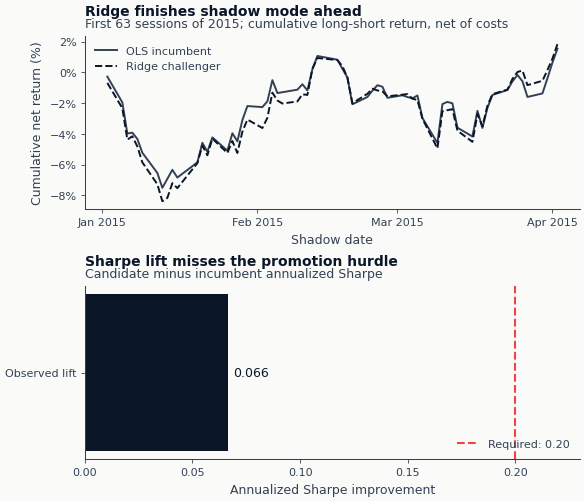

In [26]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)
draw_shadow_panel(axes[0])
draw_hurdle_panel(axes[1])
fig.show()

## Key Takeaways

1. Author-chosen roles must be labeled as illustrative rather than presented as historical
   point-in-time model selection.
2. Per-date Spearman IC can describe fixed pre-rollout artifacts without choosing their roles.
3. Shadow mode can reveal a positive candidate result without justifying promotion.
4. A minimum-effect gate prevents a small improvement from becoming an automatic capital
   allocation.
5. Rejection is a complete rollout outcome: when one required gate fails, A/B testing and staged
   capital do not begin.

**Next**: See `04_circuit_breakers` for the controls that protect models which do qualify for live
operation.